# 01 Simple Neural Network

## 📚 Learning Objectives

By completing this notebook (~20 min), you will:
- Build a feedforward neural network with Keras/TensorFlow
- Train it on real data (MNIST digits) and see loss/accuracy
- Understand why we use a neural net instead of hand-coded rules for this task

---

## 🌍 Real life

**Where is this used?** Handwritten digit recognition is used in **postal sorting**, **form scanning**, **bank check reading**, and **captcha systems**.

**In this notebook we use** a **feedforward neural network** to **classify handwritten digits (0–9)**. We use it **instead of** hand-coded rules or simple ML (e.g. one rule per digit) **because** the network **learns features from data**; we don't have to design the features by hand.

---

**📌 Covers slide(s):** **01** — Anatomy of NN, TensorFlow, layers, fit(), loss; **23** — Keras Sequential, callbacks. *Do this notebook after those slides.*

**Before starting:** Run the imports cell below. If TensorFlow fails with a **charset_normalizer** or **md__mypyc** error, fix the environment: run in a terminal `pip install --upgrade charset-normalizer requests`, then restart the kernel. For other errors, see `DOCS/COLAB_SETUP.md`.


## Theory (short)

- A **neural network** = layers of neurons: input → hidden layer(s) → output.
- Each layer applies **weights** and an **activation function** (e.g. ReLU).
- **Training**: forward pass → compute **loss** (how wrong we are) → **backpropagation** (gradients) → **optimizer** updates weights.
- **Data flow:** input image → flatten → Dense(128) → ReLU → Dense(10) → Softmax → predicted class.
- We use a **feedforward NN** (not CNN yet) here to keep it simple; in the next unit we'll use CNNs for images to use spatial structure.


## 📥 Inputs & 📤 Outputs

**Inputs:** MNIST dataset (60k training + 10k test images, 28×28 grayscale digits), TensorFlow/Keras, NumPy, Matplotlib.

**Dataset:** Real — MNIST (handwritten digits). Used so the example mimics real-world digit recognition.

**Outputs:** One figure with two plots (training/validation loss and accuracy), test accuracy number, and 5 sample predictions printed as "true label → predicted label".


In [1]:
# Step 1: Imports (run this first)
import numpy as np
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    print(f"TensorFlow {tf.__version__}")
    print("✅ Imports OK. If you see errors, check DOCS/COLAB_SETUP.md")
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ TensorFlow failed: broken or incompatible charset_normalizer (used by requests).")
        print("   Fix: In a terminal, run:")
        print("   pip install --upgrade charset-normalizer requests")
        print("   Then restart the kernel and run this cell again.")
        raise RuntimeError("Fix environment: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    print("⚠️ TensorFlow failed:", e)
    print("   See DOCS/COLAB_SETUP.md or run: pip install tensorflow")
    raise

TensorFlow 2.13.0
✅ Imports OK. If you see errors, check DOCS/COLAB_SETUP.md


In [2]:
# Step 2: Load MNIST (real dataset used in research and industry)
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training samples:", x_train.shape[0], "| Image shape:", x_train.shape[1:])  # (28, 28)
print("Test samples:", x_test.shape[0])
print("Labels: 0–9 (digits)")

Training samples: 60000 | Image shape: (28, 28)
Test samples: 10000
Labels: 0–9 (digits)


In [3]:
# Step 3: Preprocess — normalize to 0–1 and flatten for a simple feedforward NN
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0
# Flatten 28x28 -> 784 (we use a simple NN here; CNNs would keep 2D structure)
x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

print("Shape after flatten:", x_train.shape)  # (60000, 784)

Shape after flatten: (60000, 784)


In [4]:
# Step 4: Build model — we use a feedforward NN (Dense layers) instead of hand-coded rules
# because it learns features from data; we don't design them by hand.
model = tf.keras.Sequential([
    tf.keras.layers.Dense(128, activation="relu", input_shape=(784,)),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax"),  # 10 classes (digits 0–9)
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [5]:
# Step 5: Compile — choose loss (for classification) and optimizer
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

We use **3 epochs** here so the notebook runs in ~10 min; in real projects you'd use 10–50 (or more).


In [6]:
# Step 6: Train
history = model.fit(
    x_train, y_train,
    epochs=3,
    batch_size=128,
    validation_split=0.1,
    verbose=1,
)

# After this cell you should see: loss going down, accuracy going up.
# If loss stays flat, try more epochs or check that data is normalized (0–1).

Epoch 1/3
422/422 [==============================] - 0s 733us/step - loss: 0.3603 - accuracy: 0.8976 - val_loss: 0.1383 - val_accuracy: 0.9622
Epoch 2/3
422/422 [==============================] - 0s 628us/step - loss: 0.1427 - accuracy: 0.9578 - val_loss: 0.1064 - val_accuracy: 0.9693
Epoch 3/3
422/422 [==============================] - 0s 625us/step - loss: 0.0991 - accuracy: 0.9709 - val_loss: 0.0916 - val_accuracy: 0.9740


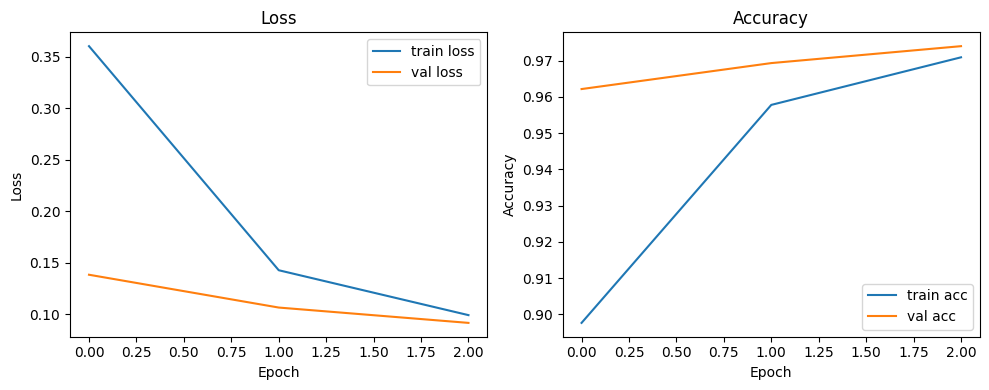

In [7]:
# Step 7: Plot loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.plot(history.history["loss"], label="train loss")
ax1.plot(history.history["val_loss"], label="val loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax2.plot(history.history["accuracy"], label="train acc")
ax2.plot(history.history["val_accuracy"], label="val acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
plt.tight_layout()
plt.show()

In [8]:
# Step 8: Evaluate on test set + sample predictions
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)
print(f"Test accuracy: {test_acc:.4f}")

# Show a few predictions: true label → predicted label
preds = model.predict(x_test[:5], verbose=0)
pred_labels = np.argmax(preds, axis=1)
print("Sample predictions (true → predicted):")
for i in range(5):
    print(f"  {y_test[i]} → {pred_labels[i]}")

Test accuracy: 0.9678
Sample predictions (true → predicted):
  7 → 7
  2 → 2
  1 → 1
  0 → 0
  4 → 4


---

## 🧩 Mini-exercise

**Try it (choose one):**
- Change the number of units in the first Dense layer (e.g. 128 → 64 or → 256), retrain for 2 epochs. What happens to loss and accuracy?
- Change `epochs` to 5 and run again. Does the model overfit (train accuracy much higher than test)?

*Add a new code cell below to try your change, then run. Then read the Summary.*

---

## ✅ Summary

**What you did:**
- Loaded MNIST, normalized and flattened the images.
- Built a feedforward NN (Dense layers) and trained it for 3 epochs.
- Plotted loss/accuracy and showed sample predictions.

**In real life you'd also:** use more epochs, save the model, and optionally use a CNN to keep image structure (see Unit 2).

**The main idea:** A neural network learns from data by updating weights using the loss and backpropagation; we don't hand-design the features.

**Next:** `05_backpropagation_detailed` shows how the gradients flow through the layers (how the network "learns").
